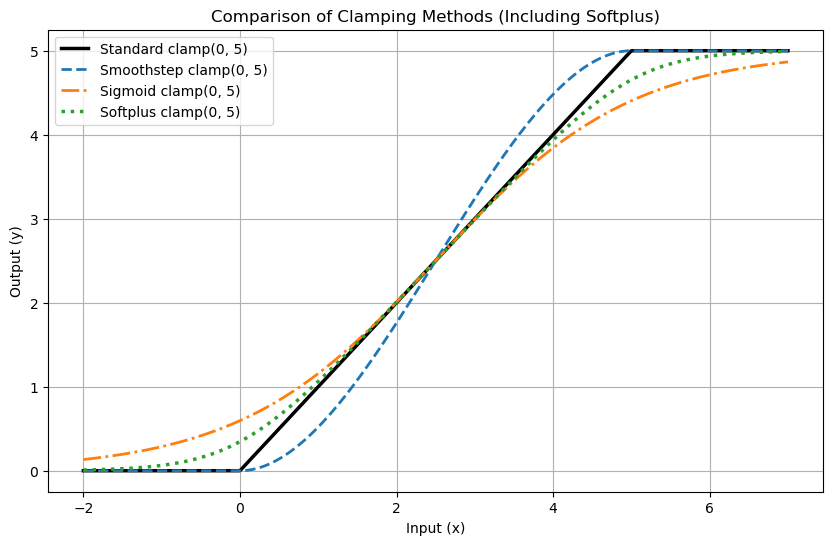

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

def smooth_clamp(x, min_val, max_val):
    t = torch.clamp((x - min_val) / (max_val - min_val), 0.0, 1.0)
    smooth_t = t * t * (3.0 - 2.0 * t)
    return min_val + (max_val - min_val) * smooth_t

def sigmoid_clamp(x, min_val, max_val, temperature=2.0):
    mid = (min_val + max_val) / 2.0
    width = max_val - min_val
    return min_val + width * torch.sigmoid(temperature * (x - mid) / (width / 2.0))

def softplus_clamp(x, min_val, max_val, beta=2.0):
    # 1. Soft approximation of max(min_val, x)
    low_clip = min_val + F.softplus(x - min_val, beta=beta)
    # 2. Soft approximation of min(max_val, low_clip) -> max_val - max(0, max_val - low_clip)
    return max_val - F.softplus(max_val - low_clip, beta=beta)

# Generate input data
x = torch.linspace(-2.0, 7.0, 500)
y_standard = torch.clamp(x, 0.0, 5.0)
y_smooth = smooth_clamp(x, 0.0, 5.0)
y_sigmoid = sigmoid_clamp(x, 0.0, 5.0, temperature=2.0)
y_softplus = softplus_clamp(x, 0.0, 5.0, beta=2.0) # Higher beta makes it closer to standard clamp

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(x.numpy(), y_standard.numpy(), label="Standard clamp(0, 5)", lw=2.5, color="black")
plt.plot(x.numpy(), y_smooth.numpy(), label="Smoothstep clamp(0, 5)", ls="--", lw=2)
plt.plot(x.numpy(), y_sigmoid.numpy(), label="Sigmoid clamp(0, 5)", ls="-.", lw=2)
plt.plot(x.numpy(), y_softplus.numpy(), label="Softplus clamp(0, 5)", ls=":", lw=2.5)
plt.grid(True)
plt.legend()
plt.title("Comparison of Clamping Methods (Including Softplus)")
plt.xlabel("Input (x)")
plt.ylabel("Output (y)")
plt.show()
